In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve)
import warnings
warnings.filterwarnings('ignore')

In [20]:
telco = pd.read_csv('data/telco.csv')

In [21]:
telco.head()

,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


In [22]:
telco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 50 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Under 30                           7043 non-null   object 
 4   Senior Citizen                     7043 non-null   object 
 5   Married                            7043 non-null   object 
 6   Dependents                         7043 non-null   object 
 7   Number of Dependents               7043 non-null   int64  
 8   Country                            7043 non-null   object 
 9   State                              7043 non-null   object 
 10  City                               7043 non-null   object 
 11  Zip Code                           7043 non-null   int64

In [25]:
PALETTE   = {'Yes': '#E74C3C', 'No': '#2E86AB'}
BG        = '#F8F9FA'
NAVY      = '#1B2A4A'
BLUE      = '#2E5FA3'
RED       = '#C0392B'
GREEN     = '#1E8449'
AMBER     = '#D68910'
GREY      = '#7F8C8D'

plt.rcParams.update({
    'figure.facecolor': BG,
    'axes.facecolor'  : BG,
    'axes.spines.top' : False,
    'axes.spines.right': False,
    'axes.labelcolor' : NAVY,
    'axes.titleweight': 'bold',
    'axes.titlesize'  : 13,
    'axes.titlecolor' : NAVY,
    'xtick.color'     : GREY,
    'ytick.color'     : GREY,
    'font.family'     : 'DejaVu Sans',
    'axes.grid'       : True,
    'grid.color'      : '#DDE1E7',
    'grid.linewidth'  : 0.6,
    'grid.alpha'      : 0.7,
})

def savefig(name):
    plt.savefig(f'/content/{name}.png', dpi=150, bbox_inches='tight',
                facecolor=BG)
    plt.close()
    print(f'  ✔  saved → {name}.png')


In [26]:
telco.isnull().sum()

Customer ID                             0
Gender                                  0
Age                                     0
Under 30                                0
Senior Citizen                          0
Married                                 0
Dependents                              0
Number of Dependents                    0
Country                                 0
State                                   0
City                                    0
Zip Code                                0
Latitude                                0
Longitude                               0
Population                              0
Quarter                                 0
Referred a Friend                       0
Number of Referrals                     0
Tenure in Months                        0
Offer                                3877
Phone Service                           0
Avg Monthly Long Distance Charges       0
Multiple Lines                          0
Internet Service                  

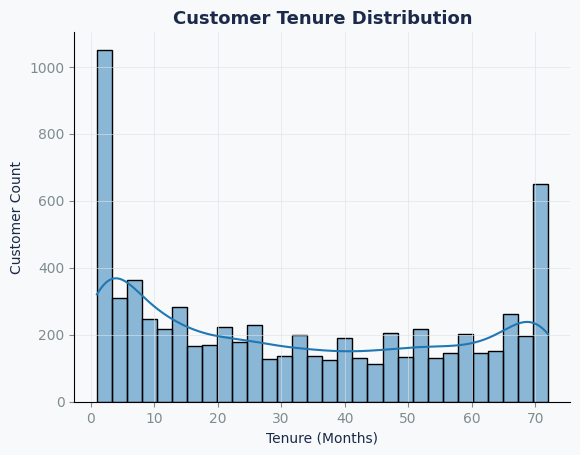

In [30]:
sns.histplot(data=telco, x='Tenure in Months', bins=30, kde=True)
plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure (Months)")
plt.ylabel("Customer Count")
plt.show()

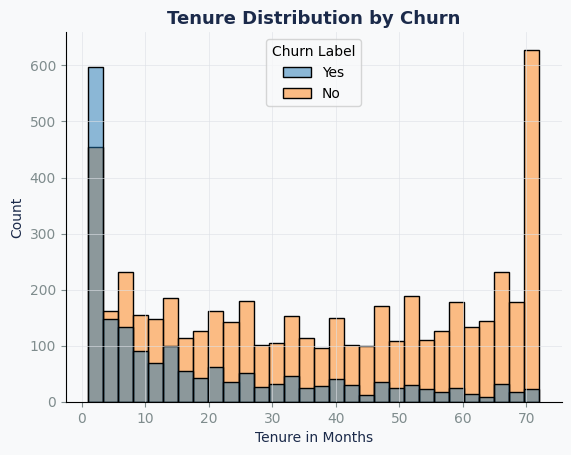

In [31]:
sns.histplot(data=telco, x='Tenure in Months', hue='Churn Label', bins=30)
plt.title("Tenure Distribution by Churn")
plt.show()

In [33]:
numeric_cols = telco.select_dtypes(include=['int64','float64'])
print(numeric_cols.columns)

Index(['Age', 'Number of Dependents', 'Zip Code', 'Latitude', 'Longitude',
       'Population', 'Number of Referrals', 'Tenure in Months',
       'Avg Monthly Long Distance Charges', 'Avg Monthly GB Download',
       'Monthly Charge', 'Total Charges', 'Total Refunds',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Revenue', 'Satisfaction Score', 'Churn Score', 'CLTV'],
      dtype='object')


In [34]:
corr_matrix = numeric_cols.corr()

print(corr_matrix)

                                        Age  Number of Dependents  Zip Code  \
Age                                1.000000             -0.119000 -0.008183   
Number of Dependents              -0.119000              1.000000  0.016493   
Zip Code                          -0.008183              0.016493  1.000000   
Latitude                          -0.010305              0.029081  0.894769   
Longitude                          0.007612             -0.024271 -0.790564   
Population                        -0.018881             -0.015486 -0.424067   
Number of Referrals               -0.025141              0.278003  0.001463   
Tenure in Months                   0.009927              0.108237  0.007146   
Avg Monthly Long Distance Charges -0.011749             -0.007324  0.005894   
Avg Monthly GB Download           -0.376595              0.129966 -0.010998   
Monthly Charge                     0.144685             -0.131837 -0.010775   
Total Charges                      0.059684         

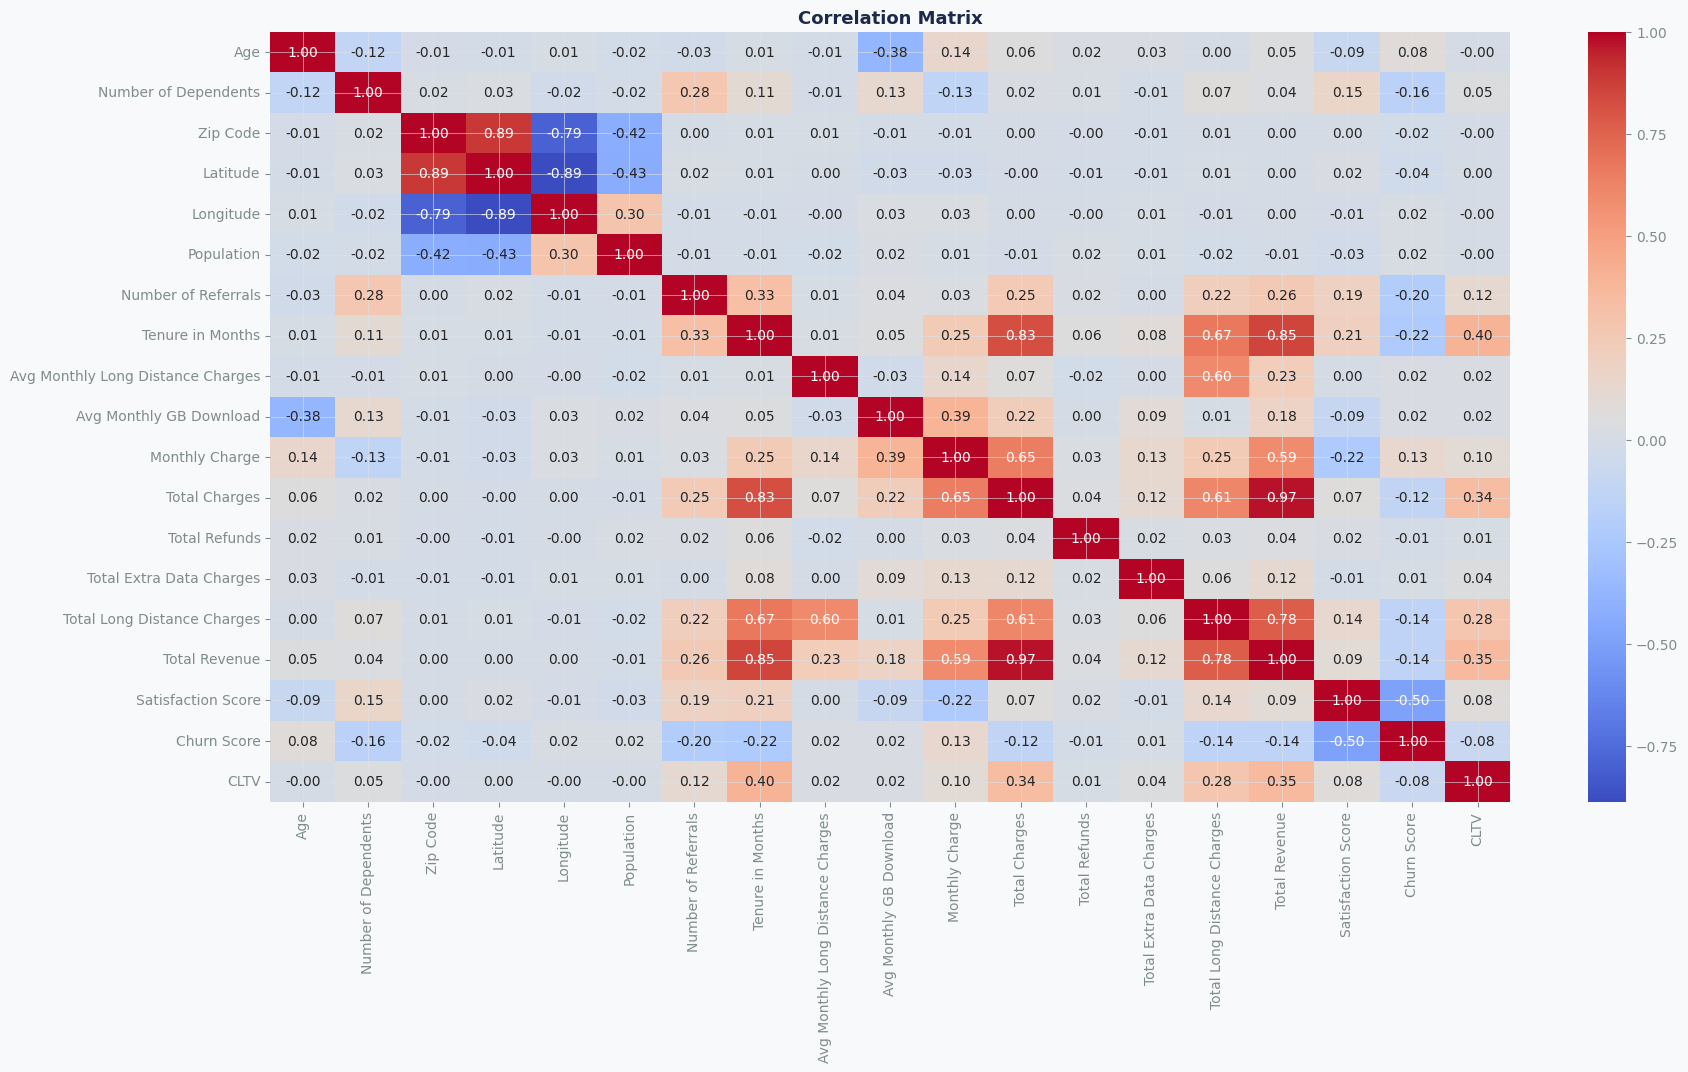

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix")
plt.show()

In [37]:
telco['Churn_binary'] = telco['Churn Label'].map({'Yes':1,'No':0})

In [38]:
corr_with_churn = telco.corr(numeric_only=True)['Churn_binary'].sort_values()

print(corr_with_churn)

Satisfaction Score                  -0.754649
Tenure in Months                    -0.352861
Number of Referrals                 -0.286540
Total Long Distance Charges         -0.223756
Total Revenue                       -0.223003
Number of Dependents                -0.218780
Total Charges                       -0.198546
CLTV                                -0.127463
Latitude                            -0.041546
Total Refunds                       -0.033709
Zip Code                            -0.016289
Total Extra Data Charges             0.007139
Avg Monthly Long Distance Charges    0.008120
Longitude                            0.024052
Avg Monthly GB Download              0.048868
Population                           0.051649
Age                                  0.115760
Monthly Charge                       0.193356
Churn Score                          0.660772
Churn_binary                         1.000000
Name: Churn_binary, dtype: float64


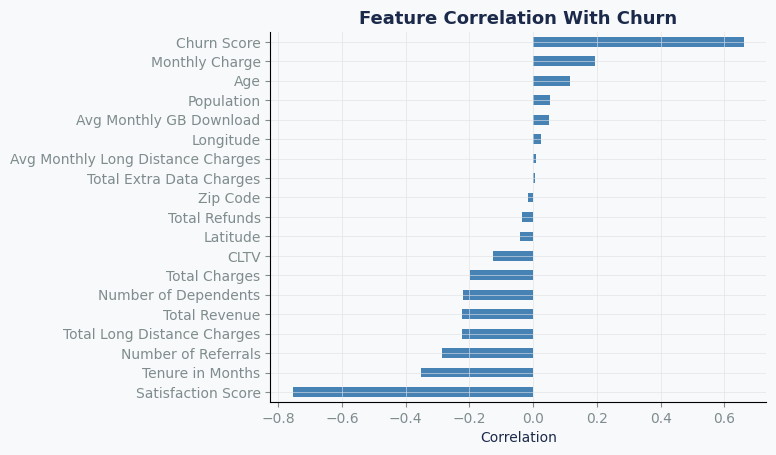

In [39]:
corr_with_churn.drop('Churn_binary').plot(
    kind='barh',
    color='steelblue'
)

plt.title("Feature Correlation With Churn")
plt.xlabel("Correlation")
plt.show()